In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [2]:
df = pd.read_csv("data/04-insurance.csv")
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


## Regression with NN

In [3]:
# Data spliting and scaling
X = df.drop(columns=["charges"]).values
y = df["charges"].values.reshape(-1, 1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# Convert to tersors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

In [5]:
# Create model
class RegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = RegressionModel(X_train.shape[1]).to(device)

In [6]:
# Loss + Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
# Training loop
epochs = 100
batch_size = 32

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    
    permutation = torch.randperm(X_train_t.size(0))
    
    epoch_loss = 0
    
    for i in range(0, X_train_t.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_X = X_train_t[indices]
        batch_y = y_train_t[indices]

        optimizer.zero_grad()
        
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test_t)
        val_loss = criterion(val_pred, y_test_t).item()
        val_losses.append(val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss={epoch_loss:.2f}, Val Loss={val_loss:.2f}")

Epoch 0: Train Loss=11033309536.00, Val Loss=323406880.00
Epoch 10: Train Loss=10480014088.00, Val Loss=306713952.00
Epoch 20: Train Loss=7697783332.00, Val Loss=215636096.00
Epoch 30: Train Loss=3731472476.00, Val Loss=101108816.00
Epoch 40: Train Loss=1776901628.00, Val Loss=47783744.00
Epoch 50: Train Loss=1297149657.00, Val Loss=34967608.00
Epoch 60: Train Loss=1220010287.00, Val Loss=32517762.00
Epoch 70: Train Loss=1184847405.00, Val Loss=31797008.00
Epoch 80: Train Loss=1198074949.00, Val Loss=31525616.00
Epoch 90: Train Loss=1183601686.00, Val Loss=31313254.00


In [8]:
# Evaluation
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).cpu().numpy()

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 4004.4366712590954
R2: 0.799198042687316


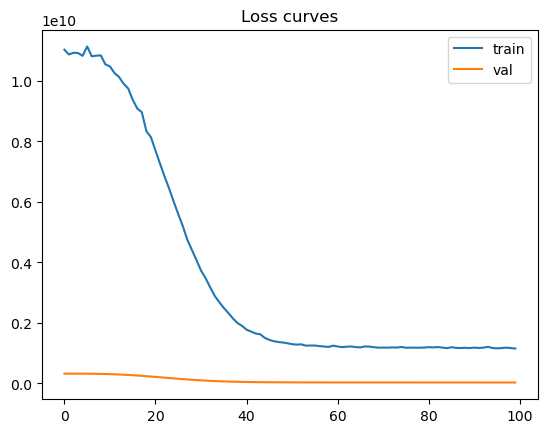

In [9]:
# Visualization
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend()
plt.title("Loss curves")
plt.show()

## Classification with NN

In [10]:
# Divide all records according to charges into three groups and encode the groups
bins = [0, 10000, 30000, np.inf]
labels = [0, 1, 2]

df["charge_class"] = pd.cut(df["charges"], bins=bins, labels=labels)

X = df.drop(columns=["charges", "charge_class"]).to_numpy()
y = df["charge_class"].astype(int).to_numpy()

In [11]:
# Scaling and split
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

In [13]:
# Model
class ClassificationModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.net(x)

model = ClassificationModel(X_train.shape[1]).to(device)

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [15]:
# Training loop
epochs = 100

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()
    
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.1586
Epoch 10, Loss: 1.0451
Epoch 20, Loss: 0.9394
Epoch 30, Loss: 0.8467
Epoch 40, Loss: 0.7596
Epoch 50, Loss: 0.6738
Epoch 60, Loss: 0.5972
Epoch 70, Loss: 0.5350
Epoch 80, Loss: 0.4877
Epoch 90, Loss: 0.4519


In [16]:
# Evaluate
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    preds = torch.argmax(logits, dim=1).cpu().numpy()

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.8805970149253731
